## Project Scope

**Dataset:** Oxford Pets, a subset of 10-12 breeds (out of 37) to keep training fast.

**Why Oxford Pets over CIFAR-10:** Real photographs with variable sizes force realistic preprocessing: resize decisions, proper augmentation, annotation file parsing. CIFAR-10's 32x32 pickle files skip all of that. The tradeoff is lower from-scratch accuracy (~50-70% on 10 breeds vs ~90% on CIFAR-10), but the pipeline practice is more representative of real CNN work.

**Image size:** Resize to 64x64 or 128x128. Larger = more detail but needs deeper network and longer training.

**Goal:** Build and train a from-scratch CNN (stride-2, batchnorm, 1cycle, augmentation) on real photos. Solidify the concepts from the L11 teaching notebooks by implementing them independently.

## Project Tasks

### Phase 1: Data Exploration

*Goal: Know your data before writing any model code.*

**Task 1.1: Load and inspect**
- **CIFAR-10:** `torchvision.datasets.CIFAR10(...)`, one line, 50K training images
- **Oxford Pets:** Parse `trainval.txt`, extract breed names from filenames, filter to your subset
- Image count, number of classes, class balance

**Task 1.2: Visualize samples**
- Display a grid of images with their labels
- Can you tell the classes apart? What visual features distinguish them?
- **Oxford Pets:** Note the image size variation. Real photos have different dimensions

**Task 1.3: Check image dimensions**
- **CIFAR-10:** Fixed 32x32, skip this step
- **Oxford Pets:** Check min/max/mean width and height. This determines your resize target (64x64, 128x128)

### Phase 2: Preprocessing & Augmentation

*Goal: Prepare data with CNN-specific transforms. This is the biggest difference from MLP.*

**Task 2.1: Resize to uniform dimensions**
- **CIFAR-10:** Already uniform, skip
- **Oxford Pets:** All images must be the same size for batching. 128x128 is a good balance of detail vs training speed. `RandomResizedCrop` for training, `Resize` + `CenterCrop` for validation

**Task 2.2: Normalize per-channel**
- Compute mean and std per color channel across your training images
- **CIFAR-10:** mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)
- **Oxford Pets:** Compute your own, or use ImageNet values: mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)
- Why per-channel? RGB channels have different statistical properties

**Task 2.3: Design augmentation (training only)**

| Augmentation | What it does | When to use |
|--------------|--------------|-------------|
| `RandomHorizontalFlip` | Mirror left-right | Almost always |
| `RandomCrop` with padding | Pad edges, crop back to original size | Small fixed-size images (CIFAR) |
| `RandomResizedCrop` | Crop random region, resize to target | Variable-size images (Pets, Flowers) |
| `ColorJitter` | Adjust brightness/contrast/saturation | Color-dependent tasks |
| `RandomRotation` | Rotate by random angle | When rotation is plausible |

Augmentation helps CNNs because they understand spatial structure. Showing the same image shifted, flipped, or cropped teaches translation and orientation invariance. MLPs gained almost nothing from this.

**Task 2.4: Build transform pipelines**

| Set | CIFAR-10 | Oxford Pets |
|-----|----------|-------------|
| Training | `RandomCrop(32, padding=4)` > `RandomHorizontalFlip` > `ToTensor` > `Normalize` | `RandomResizedCrop(128)` > `RandomHorizontalFlip` > `ToTensor` > `Normalize` |
| Validation | `ToTensor` > `Normalize` | `Resize(144)` > `CenterCrop(128)` > `ToTensor` > `Normalize` |

Key rule: validation/test data is NEVER augmented.

### Phase 3: PyTorch Data Pipeline

**Task 3.1: Create datasets with transforms**
- **CIFAR-10:** `torchvision.datasets.CIFAR10(root, train=True, transform=...)`
- **Oxford Pets:** Subclass `Dataset` with `__init__`, `__len__`, `__getitem__`. The `__getitem__` loads the image from disk, applies transforms, returns (image, label). Map breed names to integer labels (0 to num_classes-1).

**Task 3.2: Train/val split**
- **CIFAR-10:** Has a built-in test set. Split training 80/20 for train/val, or use the test set as validation.
- **Oxford Pets:** Split `trainval.txt` into ~80% train, 20% val. Use `random_split` or sklearn's `train_test_split`. Save `test.txt` for final evaluation.

**Task 3.3: Create DataLoaders**
- `batch_size`: 64-128 is a good CNN starting point
- `shuffle=True` for training, `False` for validation
- `num_workers=2-4` for faster data loading
- `pin_memory=True` when using GPU

**Task 3.4: Verify pipeline**
- Grab one batch: `images, labels = next(iter(train_loader))`
- Check shape: should be `(batch_size, 3, H, W)`, NOT flattened like MLP
- Display a few augmented training images to verify transforms look reasonable

### Phase 4: Model Architecture

*This is where everything changes from MLP.*

**Task 4.1: Build a conv helper**

The building block for every layer:
```
Conv2d(stride=2, padding=ks//2) > BatchNorm2d > ReLU
```

- `stride=2` halves spatial dimensions each layer (replaces MaxPool)
- `padding=ks//2` preserves dimensions before stride shrinks them
- BN before ReLU is the modern default (Conv > BN > ReLU)
- Final layer: no BN, no activation (raw logits for CrossEntropyLoss)

**Task 4.2: Design your CNN**

Track spatial dimensions through each layer.

**CIFAR-10 (32x32):**

| Layer | Channels | Spatial | Notes |
|-------|----------|---------|-------|
| Input | 3 | 32x32 | RGB image |
| conv1 (ks=5) | 16 | 16x16 | ks=5: 75 inputs > 16 outputs (compressing) |
| conv2 | 32 | 8x8 | Channels double as spatial halves |
| conv3 | 64 | 4x4 | |
| conv4 | 128 | 2x2 | |
| conv5 | num_classes | 1x1 | No activation, raw logits |
| Flatten | num_classes | | Done |

**Oxford Pets (128x128):**

| Layer | Channels | Spatial | Notes |
|-------|----------|---------|-------|
| Input | 3 | 128x128 | RGB image |
| conv1 (ks=5) | 16 | 64x64 | ks=5 first layer |
| conv2 | 32 | 32x32 | Channels double as spatial halves |
| conv3 | 64 | 16x16 | |
| conv4 | 128 | 8x8 | |
| conv5 | 256 | 4x4 | |
| conv6 | 512 | 2x2 | |
| conv7 | num_classes | 1x1 | No activation, raw logits |
| Flatten | num_classes | | Done |

Design choices to understand:
- **Why ks=5 first layer?** A 3x3 kernel on 3 channels = 27 inputs > 16 outputs (expanding). 5x5 = 75 inputs > 16 outputs (compressing, better for feature extraction).
- **Why double channels?** Stride-2 cuts spatial area by 4x. Doubling channels compensates, keeping the layer's information capacity roughly balanced.
- **Why no activation on the last layer?** `CrossEntropyLoss` applies softmax internally.

**Task 4.3: Verify architecture**
- Forward pass a dummy batch, check output shape matches `num_classes`
- Count parameters and print the model to see all layer shapes

### Phase 5: Training

**Task 5.1: Setup**

| Component | Choice | Notes |
|-----------|--------|-------|
| Loss | `CrossEntropyLoss` | Standard for classification |
| Optimizer | `Adam` | LR controlled by scheduler |
| Scheduler | `OneCycleLR` | Warm-up > peak > decay |
| Epochs | 25-30 | Start here, adjust based on curves |

**CRITICAL**: `OneCycleLR` steps per BATCH, not per epoch:
```python
scheduler = OneCycleLR(optimizer, max_lr=0.01,
                       steps_per_epoch=len(train_loader),
                       epochs=num_epochs)
# Inside batch loop, AFTER optimizer.step():
scheduler.step()  # Every batch, not every epoch
```

**Task 5.2: Training loop**

Standard loop: forward > loss > backward > `optimizer.step()` > `scheduler.step()`

Track per epoch: training loss, validation loss, validation accuracy.

> **Reminder:** Move model and data to GPU: `model.to(device)` and `images, labels = images.to(device), labels.to(device)`

**Task 5.3: Save best model**

Track the best validation accuracy and save the model weights when it improves:
```python
if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(model.state_dict(), 'best_model.pth')
```

Load it back after training: `model.load_state_dict(torch.load('best_model.pth'))`. This way you keep the best checkpoint even if the model overfits in later epochs.

**Task 5.4: Plot training progress**
- Loss curves (train + val vs epoch). A growing gap = overfitting
- Accuracy curve
- LR schedule (should show 1cycle shape: ramp up then ramp down)

**Task 5.5: Monitor activation health (recommended)**

Register `forward_hook` on conv layers to record activation statistics during training:
- **Mean**: should stay near 0, not drift deeply negative
- **Std**: should stay ~1-2, not collapse toward 0 or explode
- **% near-zero**: ~50% after ReLU is healthy (normal sparsity), 90%+ means dying activations

This is how you diagnose whether batchnorm is working. If activations collapse, revisit your architecture or initialization.

### Phase 6: Evaluation & Visualization

**Task 6.1: Standard metrics**
- Final test accuracy (using your saved best model)
- **Oxford Pets:** Load `test.txt` with val transforms for final evaluation
- Confusion matrix (`sklearn.metrics.confusion_matrix` + seaborn heatmap)
- Per-class accuracy: which classes/breeds are easiest/hardest?

**Task 6.2: Visualize learned filters**
- Extract conv1 weights: shape `(out_ch, in_ch, H, W)`
- For RGB input, each filter is a tiny color image (ks x ks x 3)
- Normalize each filter to [0, 1] for display
- You should see edge detectors, color gradients, texture detectors
- Nobody designed these. The network discovered them through training

**Task 6.3: Visualize feature maps**
- Pass one image through the network, collect intermediate outputs using `register_forward_hook`
- Display feature maps at each layer (each channel = one feature map)
- Early layers: edges, textures (recognizable). Deeper layers: abstract, hard to interpret

**Task 6.4: Show predictions**
- Display correctly classified images with confidence scores
- Display misclassified images: predicted vs actual label
- Look for patterns in the failures

### Phase 7: Experimentation

*Goal: Understand what each technique contributes through systematic experiments.*

**Task 7.1: Train an MLP baseline (same notebook)**

Train a quick MLP on the same data, same preprocessing, same number of epochs. This gives you an apples-to-apples comparison: same splits, same transforms (minus augmentation), same evaluation. Compare confusion matrices side by side.

**Task 7.2: Pixel shuffle test**

Shuffle all pixels with a fixed random permutation (same permutation for every image). Retrain both your CNN and MLP on the shuffled data.
- CNN accuracy should collapse (spatial structure destroyed)
- MLP accuracy should barely change (it never used spatial structure anyway)

This is the clearest proof that your CNN is actually using spatial patterns, not just color statistics.

**Task 7.3: Ablation study**

Train these variants and record accuracy:

| Experiment | What it tests |
|------------|---------------|
| Remove BatchNorm | Impact of batchnorm on training stability |
| Remove augmentation | Impact of augmentation on generalization |
| Constant LR (no 1cycle) | Impact of LR scheduling |
| Half the channels | Impact of model capacity |
| Add/remove a conv layer | Impact of depth |

**Task 7.4: Architecture variations**

| What to try | Options |
|-------------|---------|
| Starting channels | 8, 16, 32 |
| Depth | CIFAR: 4-6 layers, Oxford Pets: 5-7 layers |
| First layer kernel | 3x3 vs 5x5 |
| Channel growth | x2 each layer vs x1.5 vs constant |

**Task 7.5: Training variations**

| What to try | Options |
|-------------|---------|
| max_lr (OneCycleLR) | 0.001, 0.003, 0.01, 0.03 |
| Epochs | 15, 25, 50 |
| Batch size | 64, 128, 256 |
| Optimizer | Adam vs SGD(momentum=0.9) |

**Task 7.6: Document findings**
- What was your best accuracy?
- What had the biggest single impact: BN, augmentation, 1cycle, or architecture?
- Where does the model still fail? Why?
- Compare parameter count vs accuracy across your experiments

### What's Next

Project #2 is **fine-tuning a pretrained model** (ResNet, EfficientNet, ConvNeXt) on a harder dataset. You'll see how a model trained on millions of images transfers its knowledge to your task, and why that makes from-scratch training obsolete for most real-world problems.

*Updated: 2026_03_08*

### Start

1. Data analysis
2. preprocessing
3. Dataloaders
4. Model architecture
5. Training
6. Evaluation
7. Tuning / Experimentation

### Data analysis 

- The dataset is split into trainval and test. trainval will be used to create a split between train and validation datasets, and test is generally not used until the very end to avoid bias. This means the providers of the dataset already did a split for us - of course we could merge it as we please, but we'll stick with it and only bring out test at the very end. 
- list.txt is just a complete collection of all images (read the instructions in it!)

In [127]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

DATA_PATH = Path("/home/ua-tobias/datasets/oxford_pets")

Using: cuda


### we'll create a subset if 7 cat breeds and 7 dog breeds - you could skip this and try to train on the entire dataset, it's just to make training faster
- We use the trainval (training dataset)

In [128]:
df

,filename,class_id,species,breed
0,Abyssinian_100,1,1,Abyssinian
1,Abyssinian_101,1,1,Abyssinian
2,Abyssinian_102,1,1,Abyssinian
3,Abyssinian_103,1,1,Abyssinian
4,Abyssinian_104,1,1,Abyssinian
...,...,...,...,...
1380,Maine_Coon_211,21,1,Maine_Coon
1381,Maine_Coon_213,21,1,Maine_Coon
1382,Maine_Coon_214,21,1,Maine_Coon
1383,Maine_Coon_217,21,1,Maine_Coon


### How big are these images?

We need uniform dimensions to batch images into tensors. Let's check the range. This tells us what resize target makes sense (64x64? 128x128?) and how much cropping/stretching we'll be doing.

In [129]:
# Check image dimensions across the dataset
widths, heights = [], []
for filename in df["filename"]:
    img = Image.open(DATA_PATH / "images" / f"{filename}.jpg")
    w, h = img.size
    widths.append(w)
    heights.append(h)

print(f"Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Images: {len(widths)}")

Width  - min: 114, max: 3264, mean: 426
Height - min: 108, max: 2606, mean: 376
Images: 1385


### class imbalance?
nope! seems well rounded, which is good - that will make things easier later. 

In [130]:
df["breed"].value_counts()

breed
Abyssinian                   100
american_bulldog             100
american_pit_bull_terrier    100
basset_hound                 100
beagle                       100
Bengal                       100
Birman                       100
boxer                        100
British_Shorthair            100
chihuahua                    100
Maine_Coon                   100
Bombay                        96
english_cocker_spaniel        96
Egyptian_Mau                  93
Name: count, dtype: int64

## Preprocessing
Lets think about what we'll want to do.

- Resizing images to make sure they have a consistent size (transformation)
- Augmentation (rotating, etc?)


### Transformation prep
Transformation means we'll do CPU-bound tasks to prep the images, which is generally called augmentation. 
Among that, resizing the images is the most important, but then we can do more in order to help the model generalize better.

  1. RandomResizedCrop: picks a random region of the original photo (could be 20% of it, could be 90%), then resizes that crop to 128x128. So the model sees zoomed-in and zoomed-out views.
  2. RandomHorizontalFlip: 50% chance of mirroring left-right. A beagle facing left should be classified the same as one facing right.
  3. ToTensor: converts to a PyTorch tensor, scales pixels from 0-255 to 0-1.
  4. Normalize: shifts and scales each channel so the values are centered around 0.

In [131]:
from torchvision import transforms

IMG_SIZE = 128

# Training: augmentation + resize in one step
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Validation: resize slightly larger, then center crop to target size (no augmentation)
# We dont randomize these since validation needs to be consistent. 
val_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 16),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Train transforms: RandomResizedCrop → RandomHorizontalFlip → ToTensor → Normalize")
print(f"Val transforms: Resize({IMG_SIZE + 16}) → CenterCrop({IMG_SIZE}) → ToTensor → Normalize")

Image size: 128x128
Train transforms: RandomResizedCrop → RandomHorizontalFlip → ToTensor → Normalize
Val transforms: Resize(144) → CenterCrop(128) → ToTensor → Normalize


## Building the data pipeline

Now we need to go from raw images on disk to PyTorch tensors the model can eat. Three steps: map breed names to integer labels, build a custom `Dataset` class that loads images on-the-fly, then wrap it in `DataLoader` for batching.

In [132]:
# Map breed names to integer labels
breed_to_label = {breed: i for i, breed in enumerate(selected_breeds)}
print(breed_to_label)

{'Abyssinian': 0, 'Bengal': 1, 'Birman': 2, 'Bombay': 3, 'British_Shorthair': 4, 'Egyptian_Mau': 5, 'Maine_Coon': 6, 'american_bulldog': 7, 'american_pit_bull_terrier': 8, 'basset_hound': 9, 'beagle': 10, 'boxer': 11, 'chihuahua': 12, 'english_cocker_spaniel': 13}


Unlike CIFAR-10 (where all images are the same size and can be loaded into one big tensor), real-world image datasets have variable-sized files on disk. We need a custom `Dataset` class that loads each image individually and applies transforms on-the-fly. This is the standard pattern for most image datasets outside of CIFAR/MNIST.

The DataLoader calls `__getitem__(idx)` each time it needs an image. For a batch of 64, it calls it 64 times, each time opening the file from disk, applying transforms (crop, flip, normalize), and returning the tensor + label. The DataLoader stacks those into a batch. This happens fresh every epoch, so with random augmentation the model never sees the exact same input twice.

In [133]:
class PetsDataset(Dataset):
    def __init__(self, dataframe, img_dir, breed_to_label, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.breed_to_label = breed_to_label
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / f"{row['filename']}.jpg"
        image = Image.open(img_path).convert("RGB")
        label = self.breed_to_label[row["breed"]]

        if self.transform:
            image = self.transform(image)

        return image, label

### Train / Val split

Split the dataframe into 80% train, 20% validation using `stratify` to ensure each breed is represented proportionally in both sets. Each split gets its own `PetsDataset`: training with augmentation transforms, validation without.

In [134]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["breed"])

train_dataset = PetsDataset(train_df, DATA_PATH / "images", breed_to_label, transform=train_transforms)
val_dataset = PetsDataset(val_df, DATA_PATH / "images", breed_to_label, transform=val_transforms)

print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")

Train: 1108 images
Val: 277 images


### Dataloaders

In [135]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

### Check out the batches
A rank 4 tensor, meaning 64 images, each image has 3 channels (which means 3 matrices for image), where each matrix is 128x128

In [136]:
images, labels = next(iter(train_dataloader))                                                                                                                                         
print(f"Batch shape: {images.shape}")  # Should be (64, 3, 128, 128)                                                                                                                  
print(f"Labels shape: {labels.shape}")  # Should be (64,)    

Batch shape: torch.Size([64, 3, 128, 128])
Labels shape: torch.Size([64])


## Creating the model

Quick refresher on the building blocks and how to reason about their values:

**Conv2d** slides a small kernel across the image, producing a feature map that highlights patterns like edges, textures, or shapes. Each kernel learns its own pattern during training. **Kernel size** controls the scale of patterns the layer can detect. 3x3 is the default for nearly everything because it's the smallest size that captures spatial patterns (up, down, left, right, diagonals). The main exception is the first layer, where 5x5 is common because raw pixels need a slightly wider view to capture meaningful structure. A 5x5 kernel sees a 25-pixel neighborhood per channel vs only 9 for a 3x3, giving the first layer more context to work with when all it has is raw RGB values.

**Channels** = how many feature maps are stacked at a given layer. The input has 3 channels (R, G, B), each just a 2D matrix of pixel values for that color. `Conv2d(3, 16, ...)` means 16 kernels, each sliding across the input and producing its own feature map. So the output has 16 channels: 16 different "views" of the image. One kernel might learn to detect horizontal edges, another vertical edges, another color gradients. Deeper layers combine these into higher-level features (textures, shapes, object parts).

**What is a feature map?** A feature map is a heatmap showing where a kernel's pattern was detected in the input, and how strongly. High values = strong match at that position, near zero = pattern not present. A horizontal-edge kernel produces a feature map lit up wherever horizontal edges exist, and dark everywhere else. So each feature map answers a spatial question: "where in this image does pattern X appear, and how strongly?"

Important: the pattern being detected belongs to the **kernel as a whole**, not to any individual slice. When a kernel has multiple slices (one per input channel), each slice is just a set of weights controlling how much that input feature map contributes. Slice 1 might have large values ("pay attention to FM1"), slice 3 might be near-zero ("ignore FM3"). But the "pattern" only emerges from the full sum across all slices. One slice on its own doesn't mean anything. The kernel as a whole learns to detect a pattern that spans across multiple input feature maps, like "horizontal edges (FM1) near vertical edges (FM2) but not where there's a color gradient (FM3)."

In later layers, the "patterns" become combinations of earlier patterns. A Conv2 kernel that combines a horizontal-edge map with a vertical-edge map is effectively a corner detector. By Conv6, the patterns are too abstract to interpret visually, but they represent high-level features the network has learned are useful for classification.

**Stride** controls how many pixels the kernel jumps between positions. `stride=1` means the kernel moves 1 pixel at a time, visiting every position. `stride=2` means it jumps 2 pixels, skipping every other position. Same kernel, same multiplication, just fewer stops. That's why it halves the output size. We use stride-2 everywhere because we need to go from 128x128 down to 1x1. In deeper architectures like ResNet, most layers use stride=1 and only a few use stride=2 at transition points.

**Padding** isn't really a design choice. It's a consequence of kernel size. You set `padding = kernel_size // 2` so the convolution doesn't accidentally shrink the output beyond what stride already does. 3x3 kernel = `padding=1`. 5x5 kernel = `padding=2`. You almost never pick a different value.

**BatchNorm** rescales activations to have mean ~0 and std ~1 after each conv layer. Without it, values tend to drift, getting very large or very small as they pass through layers, which kills learning. BN resets the distribution at every layer so gradients stay healthy.

**ReLU** zeroes out negative values (`max(0, value)`). Simple, but it gives the network non-linearity. Without it, stacking layers would just be one big linear transformation.

**The pattern: Conv > BN > ReLU.** Every layer follows this order, except the final one which outputs raw scores (logits) with no BN or activation. `CrossEntropyLoss` handles the softmax internally.

### The flow through the network

Each layer's kernels reach across *all* input channels, learn a weighted combination of them (not an average, a learned recipe), and sum the result into one new feature map per kernel.

- **conv1:** 16 kernels (each 5x5x3) slide across the RGB image. Each kernel sums across all 3 color channels at each position, producing 1 feature map. Result: 16 feature maps at 64x64. Each feature map is a heatmap of "where does this kernel's pattern appear?"
- **conv2:** 32 kernels (each 3x3x16) slide across those 16 feature maps. Each kernel has 16 slices (one per input FM), learns which combination of the 16 inputs matters, sums them into 1 new feature map. Result: 32 feature maps at 32x32. These represent combinations of Conv1 patterns (e.g. edges + textures = shapes).
- **conv3-6:** Same pattern. More kernels, each reaching across all previous feature maps, producing richer combinations. Spatial size halves, channel count doubles each time. The features become increasingly abstract and harder to interpret visually.

### From feature maps to prediction

After conv6, we have 512 feature maps at 2x2. Each one is a tiny heatmap answering some abstract question about the image ("how much pointy-ear texture combined with striped-fur pattern?"). But we need 14 numbers, one per breed. Two things have to happen:

**1. Collapse the spatial dimensions.** At this point we don't care *where* a pattern was found, just *how strongly*. We need to go from 2x2 per feature map to a single number. Our conv7 does this with `kernel_size=2`: a 2x2 kernel on a 2x2 feature map covers the entire thing and produces one number. That's it. 2x2 > 1x1.

**2. Combine features into class scores.** Conv7 has 14 kernels, one per breed. Each kernel has 512 slices (one per conv6 feature map). So each kernel learns a weighted combination: "if pattern 37 is strong AND pattern 204 is strong AND pattern 89 is weak, it's probably a beagle." The output is 14 numbers (one per breed), and the highest one is the prediction.

These two steps happen in a single operation. Conv7 simultaneously collapses spatial dimensions AND produces class scores. Then `Flatten` turns the 1x1x14 tensor into a flat vector of 14 values.

### The three real design decisions

1. **How many layers?** Determined by input size. Each stride-2 halves dimensions, so count how many halvings you need to reach 1x1. For 128x128: 128 > 64 > 32 > 16 > 8 > 4 > 2 > 1 = 7 layers.
2. **How many channels?** Start small (16), double each layer. Stride-2 cuts spatial area by 4x (half width x half height), so doubling channels compensates and keeps each layer's capacity roughly balanced. More channels = more capacity but more parameters and slower training.
3. **Kernel size?** 3x3 everywhere, 5x5 on the first layer. That's it.

In [137]:
class PetsCNN(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        # 128x128x3 > 64x64x16
        self.conv1 = nn.Sequential(nn.Conv2d(3, 16, kernel_size=5, stride=2, padding=2), nn.BatchNorm2d(16), nn.ReLU())
        # 64x64x16 > 32x32x32
        self.conv2 = nn.Sequential(nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU())
        # 32x32x32 > 16x16x64
        self.conv3 = nn.Sequential(nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU())
        # 16x16x64 > 8x8x128
        self.conv4 = nn.Sequential(nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        # 8x8x128 > 4x4x256
        self.conv5 = nn.Sequential(nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU())
        # 4x4x256 > 2x2x512
        self.conv6 = nn.Sequential(nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(512), nn.ReLU())
        # 2x2x512 > 1x1xnum_classes (no BN, no activation)
        self.conv7 = nn.Conv2d(512, num_classes, kernel_size=2, stride=1, padding=0)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)
        return self.flatten(x)

model = PetsCNN(num_classes=len(selected_breeds)).to(device)

# Sanity check: push a fake image through the model to verify the architecture works.
# If any layer has a shape mismatch, this crashes immediately. Better to catch it now than during training.
dummy = torch.randn(1, 3, 128, 128).to(device)  # 1 fake RGB image, 128x128 (just random noise)
print(f"Output shape: {model(dummy).shape}")  # Should be (1, 14), one prediction per class

# Count every learnable number (weights + biases) across all layers
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Output shape: torch.Size([1, 14])
Parameters: 1,604,238


### What does the CNN actually see?

Let's pass a real pet image through our (untrained) model and visualize the feature maps at each layer. Even with random weights, you'll see that the convolutions produce spatial patterns: some feature maps highlight edges, others respond to textures or color boundaries. After training, these become much more structured and interpretable.

We use `register_forward_hook` to capture the output of each conv layer as the image flows through. Each feature map is one channel of that output, displayed as a heatmap.

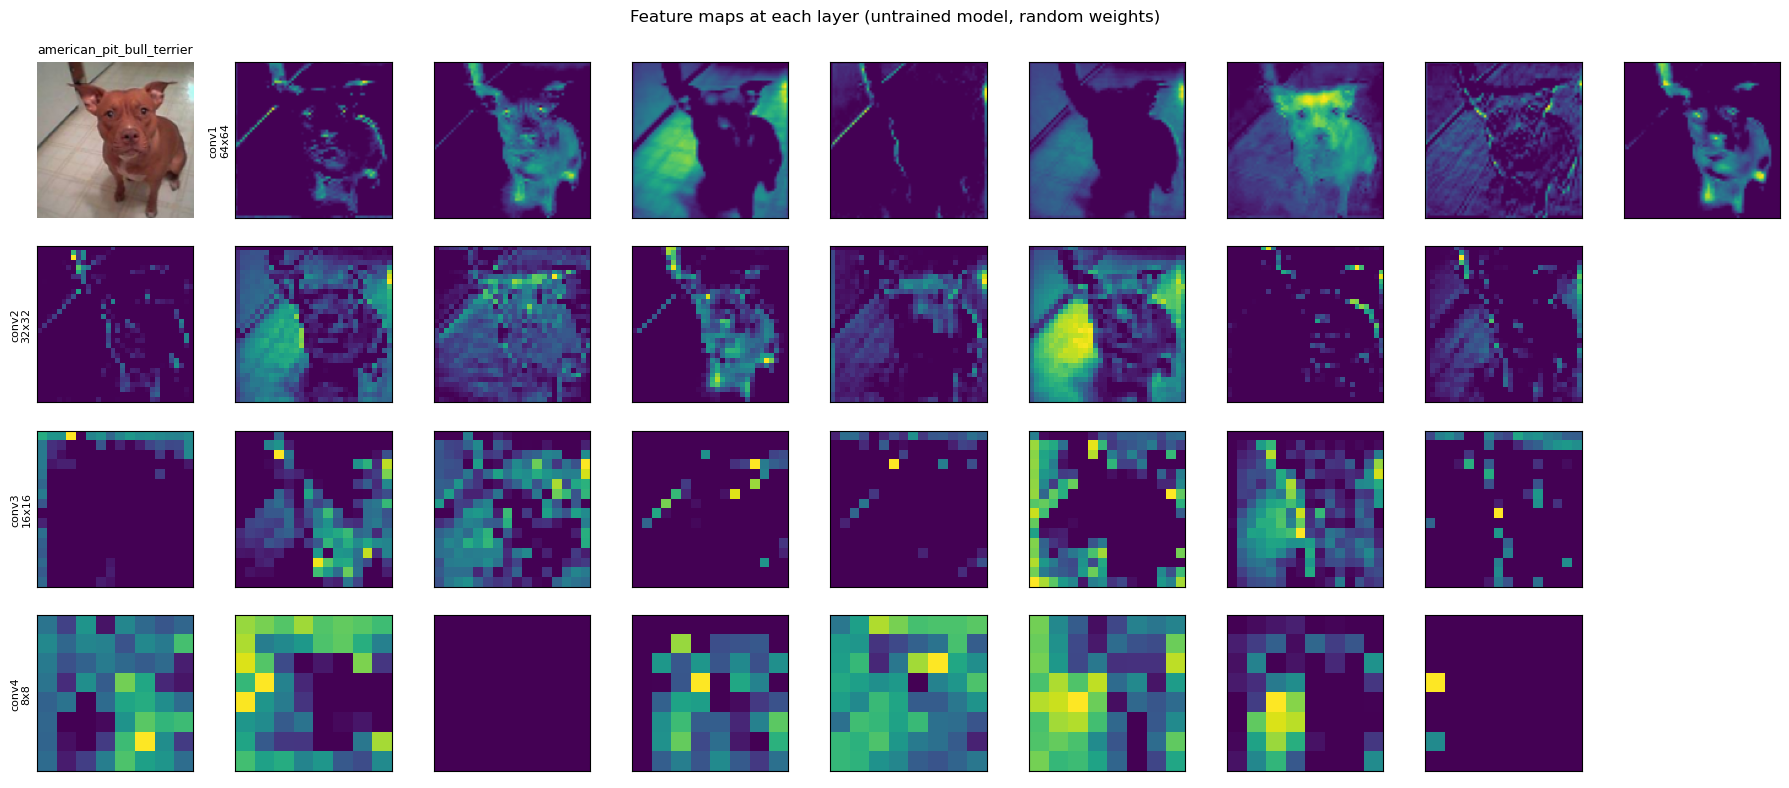

Conv1: 16 feature maps at 64x64
Conv4: 128 feature maps at 8x8
Conv6: 512 feature maps at 2x2
After training, early layers will show clear edge/texture detectors.


In [138]:
# Grab one real image from the validation set (no augmentation, consistent)
sample_img, sample_label = val_dataset[0]
label_name = [k for k, v in breed_to_label.items() if v == sample_label][0]

# Show the original image (undo normalization for display)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
display_img = (sample_img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

# Hook each conv layer to capture its output
activations = {}
hooks = []
for name in ['conv1', 'conv2', 'conv3', 'conv4', 'conv5', 'conv6']:
    layer = getattr(model, name)
    hook = layer.register_forward_hook(
        lambda module, inp, out, name=name: activations.update({name: out.detach().cpu()})
    )
    hooks.append(hook)

# Forward pass (single image, add batch dimension)
model.eval()
with torch.no_grad():
    _ = model(sample_img.unsqueeze(0).to(device))

# Remove hooks
for h in hooks:
    h.remove()

# Plot: original image + first 8 feature maps from each layer
fig, axes = plt.subplots(4, 9, figsize=(18, 8))

# Original image in top-left
axes[0, 0].imshow(display_img)
axes[0, 0].set_title(f"{label_name}", fontsize=9)
axes[0, 0].axis('off')

# Feature maps for conv1-4 (first 8 channels each, show 4 layers)
for row, layer_name in enumerate(['conv1', 'conv2', 'conv3', 'conv4']):
    fmaps = activations[layer_name][0]  # remove batch dim
    num_show = min(8, fmaps.shape[0])
    for i in range(num_show):
        ax = axes[row, i + 1] if row == 0 else axes[row, i]
        ax.imshow(fmaps[i].numpy(), cmap='viridis')
        if i == 0:
            ax.set_ylabel(f"{layer_name}\n{fmaps.shape[1]}x{fmaps.shape[2]}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    # Hide unused axes
    start = (num_show + 1) if row == 0 else num_show
    for i in range(start, 9):
        axes[row, i].axis('off')

# Hide remaining axes in first row
if 'conv1' in activations and activations['conv1'].shape[1] < 8:
    for i in range(activations['conv1'].shape[1] + 1, 9):
        axes[0, i].axis('off')

plt.suptitle("Feature maps at each layer (untrained model, random weights)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Conv1: {activations['conv1'].shape[1]} feature maps at {activations['conv1'].shape[2]}x{activations['conv1'].shape[3]}")
print(f"Conv4: {activations['conv4'].shape[1]} feature maps at {activations['conv4'].shape[2]}x{activations['conv4'].shape[3]}")
print(f"Conv6: {activations['conv6'].shape[1]} feature maps at {activations['conv6'].shape[2]}x{activations['conv6'].shape[3]}")
print("After training, early layers will show clear edge/texture detectors.")

### The Excel example as a PyTorch model

The spreadsheet `multi-channel-conv-example.xlsx` demonstrates the full CNN pipeline on a real MNIST digit (28x28). It uses hand-crafted horizontal and vertical edge detectors for Conv1, then shows multi-channel convolution in Conv2 and Conv3. Click any colored cell to trace the formula chain from input pixel all the way to class prediction. The "How It Works" tab walks through the theory behind each section.

Pipeline: Input (28x28) > Conv1 (2 FMs, 26x26) > Conv2 (4 FMs, 24x24) > Conv3 (8 FMs, 22x22) > Global Avg Pool (8 values) > Dense (10 class scores) > Prediction

**Why does this model use GAP + Dense while PetsCNN uses a final conv?** Same job, different circumstances. PetsCNN uses stride-2, so spatial dimensions shrink to 2x2 by conv6. A `kernel_size=2` conv covers the entire feature map and collapses it to 1x1 in one step. The Excel model uses stride=1 with no padding, so after 3 layers we're still at 22x22. Collapsing that with a conv would need `kernel_size=22`, which is impractical. GAP (average the whole feature map to one number) handles any spatial size cleanly. Most real architectures (ResNet, EfficientNet) use GAP even when they could use a final conv, because it's more flexible.

In [139]:
# The Excel spreadsheet as PyTorch code
# Real MNIST digit pipeline: Conv1 > Conv2 > Conv3 > GAP > Dense
class ExcelCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 28x28x1 > 26x26x2   (2 kernels, each 3x3x1)
        self.conv1 = nn.Conv2d(1, 2, kernel_size=3, stride=1, padding=0)
        # 26x26x2 > 24x24x4   (4 kernels, each 3x3x2)
        self.conv2 = nn.Conv2d(2, 4, kernel_size=3, stride=1, padding=0)
        # 24x24x4 > 22x22x8   (8 kernels, each 3x3x4)
        self.conv3 = nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=0)
        # 22x22x8 > 1x1x8     (average each FM to one number)
        self.gap = nn.AdaptiveAvgPool2d(1)
        # 8 > 10               (one score per digit class)
        self.fc = nn.Linear(8, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))   # 1ch > 2ch, edges detected
        x = F.relu(self.conv2(x))   # 2ch > 4ch, edge combinations
        x = F.relu(self.conv3(x))   # 4ch > 8ch, deeper patterns
        x = self.gap(x)             # spatial collapsed to 1x1
        x = x.view(x.size(0), -1)  # flatten: (batch, 8)
        x = self.fc(x)             # 8 features > 10 class scores
        return x

excel_model = ExcelCNN()
dummy = torch.randn(1, 1, 28, 28)  # 1 grayscale 28x28 image (MNIST)
print(f"Output shape: {excel_model(dummy).shape}")  # (1, 10)

for name, param in excel_model.named_parameters():
    if 'weight' in name:
        print(f"{name}: {param.shape}")
# conv1.weight: (2, 1, 3, 3)  = 2 kernels, depth 1
# conv2.weight: (4, 2, 3, 3)  = 4 kernels, depth 2 (sees both Conv1 FMs)
# conv3.weight: (8, 4, 3, 3)  = 8 kernels, depth 4 (sees all 4 Conv2 FMs)
# fc.weight:    (10, 8)       = 10 classes, 8 features each

Output shape: torch.Size([1, 10])
conv1.weight: torch.Size([2, 1, 3, 3])
conv2.weight: torch.Size([4, 2, 3, 3])
conv3.weight: torch.Size([8, 4, 3, 3])
fc.weight: torch.Size([10, 8])


## Training the model 

### MLP baseline

Before training our CNN, let's establish a baseline with an MLP on the same data. The MLP flattens each image into a single vector of 49,152 numbers (3x128x128) and feeds it through dense layers. It has no concept of spatial structure: pixels that are next to each other in the image are just numbers in a list. Same optimizer, same scheduler, same epochs, so the comparison is fair.

In [140]:
# MLP baseline: same data, same training setup, no spatial awareness
mlp_model = nn.Sequential(
    nn.Flatten(),                          # 3x128x128 = 49,152 inputs
    nn.Linear(3 * 128 * 128, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, len(selected_breeds))   # 14 class scores
).to(device)

mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.01)
mlp_criterion = nn.CrossEntropyLoss()
mlp_epochs = 40
mlp_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    mlp_optimizer, max_lr=0.01,
    steps_per_epoch=len(train_dataloader),
    epochs=mlp_epochs
)

mlp_best_acc = 0.0
for epoch in range(mlp_epochs):
    mlp_model.train()
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        mlp_optimizer.zero_grad()
        loss = mlp_criterion(mlp_model(images), labels)
        loss.backward()
        mlp_optimizer.step()
        mlp_scheduler.step()

    mlp_model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            correct += (mlp_model(images).argmax(1) == labels).sum().item()
    acc = correct / len(val_dataset)
    mlp_best_acc = max(mlp_best_acc, acc)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"MLP Epoch {epoch+1:2d}/{mlp_epochs} | val_acc: {acc:.3f}")

print(f"\nMLP best accuracy: {mlp_best_acc:.3f} (random guess: {1/len(selected_breeds):.3f})")
print(f"MLP params: {sum(p.numel() for p in mlp_model.parameters()):,}")

MLP Epoch  1/40 | val_acc: 0.166
MLP Epoch 10/40 | val_acc: 0.170
MLP Epoch 20/40 | val_acc: 0.242
MLP Epoch 30/40 | val_acc: 0.264
MLP Epoch 40/40 | val_acc: 0.282

MLP best accuracy: 0.285 (random guess: 0.071)
MLP params: 25,302,798


Before we write the training loop, we need three components:

**Loss function, `CrossEntropyLoss`:** Measures how wrong the model's predictions are. It takes the raw logit scores from our last layer and computes how far they are from the correct class. Lower = better.

**Optimizer, `Adam`:** Decides *how* to update the weights after each batch. Adam is an improved version of basic gradient descent. It tracks two running averages per parameter: the mean of recent gradients (which direction to go) and the mean of recent squared gradients (how much each parameter has been fluctuating). It uses both to adapt the step size for each parameter individually. Think of it as a smarter way to walk downhill. We pass it `lr=0.01`, but the scheduler will override this.

**Scheduler, `OneCycleLR`:** Controls the learning rate *during* training. The optimizer does the actual weight updates, but the scheduler tells it how aggressively to update at each step. OneCycleLR follows a specific pattern: start with a small LR (cautious steps), ramp up to `max_lr` (bold steps), then decay back down (fine-tuning). This warmup-then-cooldown pattern consistently trains better than a fixed learning rate.

The key detail: `OneCycleLR` adjusts the LR every **batch**, not every epoch. That's why we pass `steps_per_epoch=len(train_dataloader)` so it knows how many batches per epoch to plan the full curve.

In [141]:
criterion = nn.CrossEntropyLoss()                                                                                                                                                     
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 25                                                                                                                                                                       
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.01,                                                                                                                                                           
    steps_per_epoch=len(train_dataloader),                                                                                                                                            
    epochs=num_epochs
)       

### The training loop

Each epoch has two phases. **Training:** iterate over batches, compute loss, backpropagate, update weights. **Validation:** iterate over batches with no gradient computation, just measure how well the model generalizes.

The sequence inside each training batch:
1. `optimizer.zero_grad()` - clear gradients from the previous batch
2. `outputs = model(images)` - forward pass, produces 14 scores per image
3. `loss = criterion(outputs, labels)` - how wrong are the predictions?
4. `loss.backward()` - compute gradients for every weight
5. `optimizer.step()` - nudge weights in the direction that reduces loss
6. `scheduler.step()` - adjust the learning rate (OneCycleLR steps every batch)

A few things to watch for:
- **`model.train()` vs `model.eval()`** switches BatchNorm behavior. Training mode uses batch statistics, eval mode uses running averages accumulated during training. Forgetting this is a common bug.
- **`torch.no_grad()`** in validation saves memory since we don't need gradients there.
- **`loss.item() * images.size(0)`** undoes the per-batch averaging so we can compute the correct average across the full dataset (the last batch might be smaller).

We also save the best model weights whenever validation accuracy improves. Training can overfit in later epochs, so we want to keep the peak.

In [142]:
criterion = nn.CrossEntropyLoss()                                                                                                                                                     
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 40                                                                                                                                                                      
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.01,                                                                                                                                                           
    steps_per_epoch=len(train_dataloader),                                                                                                                                            
    epochs=num_epochs
)       

history = {"train_loss": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc = 0.0

for epoch in range(num_epochs):
    # --- Training phase ---
    model.train()  # switches BatchNorm to use batch stats (not running averages)
    running_loss = 0.0

    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()              # clear gradients from previous batch (first iteration has none, but still required)
        outputs = model(images)            # forward pass: 64 images in, 64x14 scores out
        loss = criterion(outputs, labels)  # CrossEntropyLoss returns the average loss for this batch
        loss.backward()                    # compute gradient for every weight in the model
        optimizer.step()                   # Adam nudges all weights using those gradients
        scheduler.step()                   # OneCycleLR adjusts LR (steps every batch, not every epoch)

        # loss.item() is the average loss for this batch. Multiply by batch size to get the
        # total loss, so we can correctly average across all images later (last batch may be smaller)
        running_loss += loss.item() * images.size(0)

    # Divide accumulated total by number of images = correct average loss for the epoch
    train_loss = running_loss / len(train_dataset)

    # --- Validation phase ---
    model.eval()  # switches BatchNorm to use running averages (stable, no batch noise)
    val_loss = 0.0
    correct = 0

    with torch.no_grad():  # no gradients needed, saves memory and speeds up
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item() * images.size(0)
            # argmax picks the class with the highest score for each image
            correct += (outputs.argmax(dim=1) == labels).sum().item()

    val_loss /= len(val_dataset)
    val_acc = correct / len(val_dataset)

    # Save best model: training can overfit in later epochs, so we keep the peak
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_pets_cnn.pth")

    # Record metrics for plotting later
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{num_epochs} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.3f} | lr: {history['lr'][-1]:.6f}")

print(f"\nBest validation accuracy: {best_val_acc:.3f}")

Epoch  1/40 | train_loss: 2.6591 | val_loss: 2.5742 | val_acc: 0.155 | lr: 0.000565
Epoch  5/40 | train_loss: 2.5703 | val_loss: 3.7104 | val_acc: 0.184 | lr: 0.003986
Epoch 10/40 | train_loss: 2.4451 | val_loss: 2.5830 | val_acc: 0.199 | lr: 0.009386
Epoch 15/40 | train_loss: 2.2187 | val_loss: 2.2201 | val_acc: 0.292 | lr: 0.009709
Epoch 20/40 | train_loss: 2.1143 | val_loss: 2.2017 | val_acc: 0.292 | lr: 0.008093
Epoch 25/40 | train_loss: 1.9448 | val_loss: 2.2746 | val_acc: 0.282 | lr: 0.005529
Epoch 30/40 | train_loss: 1.7181 | val_loss: 2.3350 | val_acc: 0.242 | lr: 0.002803
Epoch 35/40 | train_loss: 1.5673 | val_loss: 1.9647 | val_acc: 0.386 | lr: 0.000750
Epoch 40/40 | train_loss: 1.4921 | val_loss: 1.9295 | val_acc: 0.415 | lr: 0.000000

Best validation accuracy: 0.426


### Reading the results

**40.8% accuracy** with random guess at 7% (1/14 breeds), so the model is clearly learning real patterns.

**Overfitting is visible.** Train loss drops steadily (1.91 > 1.26) but val loss only improves slightly overall (2.01 > 1.94) and actually spikes to 2.82 at epoch 10 during the LR peak. That growing gap between train and val loss means the model is memorizing training images rather than learning patterns that generalize. Not surprising with only ~80 images per breed.

**The 1cycle LR schedule is working as designed.** Both train and val loss get *worse* around epoch 10 when LR peaks at ~0.01 (big aggressive steps that temporarily destabilize training), then recover and improve as LR decays. The model does its best learning in the second half when LR is shrinking and it can fine-tune.

**Val accuracy plateaus around epoch 25.** The last 15 epochs barely help (0.404 > 0.408). The model has learned what it can from this amount of data at this capacity. More epochs won't fix this.

**What would help:** more training data (the biggest bottleneck), stronger augmentation, or a pretrained model that already knows what edges and textures look like. We'll explore some of these in Phase 7.

### Training curves

Three plots that tell the story of how training went. The loss curves show whether the model is learning and whether it's overfitting (val loss rises while train loss keeps dropping). The accuracy curve shows the metric we actually care about. The LR schedule confirms the 1cycle pattern worked as expected.

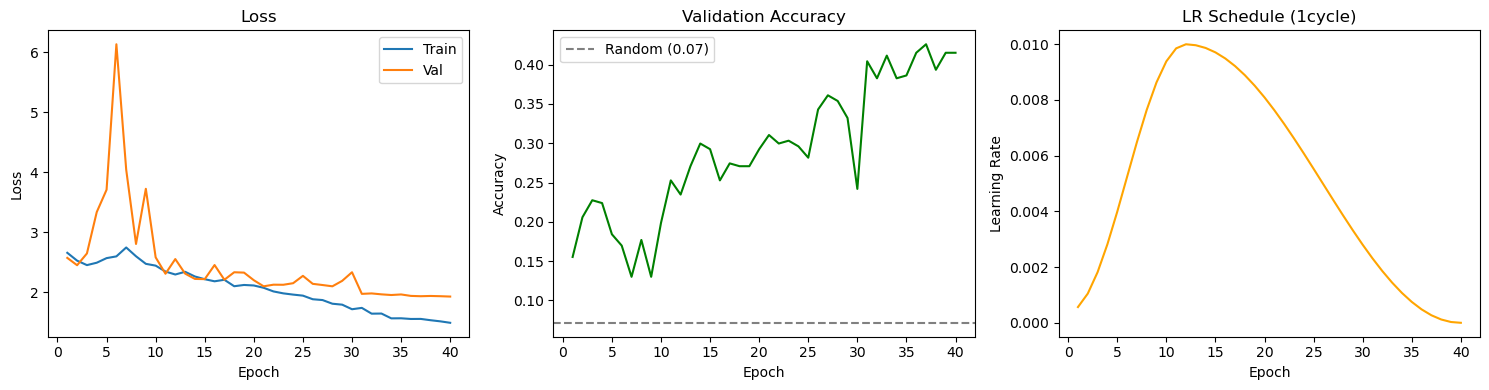

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

# Loss curves
axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, history["val_acc"], color="green")
axes[1].axhline(y=1/len(selected_breeds), color="gray", linestyle="--", label=f"Random ({1/len(selected_breeds):.2f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend()

# LR schedule
axes[2].plot(epochs_range, history["lr"], color="orange")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("LR Schedule (1cycle)")

plt.tight_layout()
plt.show()

### Activation health check

Let's verify that BatchNorm is doing its job. We'll hook into each conv layer, pass a batch through the trained model, and check three stats per layer:
- **Mean**: should be near 0 (BN centers the distribution)
- **Std**: should be around 1-2 (BN normalizes the spread)
- **% near-zero**: ~50% is healthy after ReLU (half of a centered distribution is negative, ReLU clips those to 0). 90%+ means dying activations.

This is the same `register_forward_hook` technique we used to visualize feature maps, but now we're looking at statistics instead of images.

In [144]:
# Hook every conv layer and record activation stats
act_stats = {}
hooks = []

for name in ['conv1', 'conv2', 'conv3', 'conv4', 'conv5', 'conv6']:
    layer = getattr(model, name)
    hook = layer.register_forward_hook(
        lambda module, inp, out, name=name: act_stats.update({
            name: {
                "mean": out.mean().item(),
                "std": out.std().item(),
                "near_zero": (out.abs() < 0.1).float().mean().item() * 100,  # percentage
            }
        })
    )
    hooks.append(hook)

# Pass one real training batch through the trained model
model.eval()
images, labels = next(iter(train_dataloader))
with torch.no_grad():
    _ = model(images.to(device))

for h in hooks:
    h.remove()

# Display as a table
print(f"{'Layer':<8} {'Mean':>8} {'Std':>8} {'% near-zero':>12}  Status")
print("-" * 50)
for name in ['conv1', 'conv2', 'conv3', 'conv4', 'conv5', 'conv6']:
    s = act_stats[name]
    # Healthy: mean near 0, std 0.5-3, near-zero 30-70%
    healthy = abs(s["mean"]) < 1.0 and 0.3 < s["std"] < 5.0 and s["near_zero"] < 80
    status = "ok" if healthy else "CHECK"
    print(f"{name:<8} {s['mean']:>8.3f} {s['std']:>8.3f} {s['near_zero']:>10.1f}%  {status}")

Layer        Mean      Std  % near-zero  Status
--------------------------------------------------
conv1       0.342    0.557       57.7%  ok
conv2       0.339    0.565       59.1%  ok
conv3       0.375    0.588       56.5%  ok
conv4       0.387    0.599       55.9%  ok
conv5       0.322    0.561       61.9%  ok
conv6       0.074    0.199       82.6%  CHECK


Conv1-5 look healthy: mean ~0.3 (positive because ReLU clips negatives), std ~0.5-0.6 (stable), near-zero 56-66% (normal ReLU sparsity). BatchNorm is doing its job.

Conv6 is nearly dead: std collapsed to 0.15 and 91% of activations are near-zero. That means conv7 (the classifier) is working with almost no useful signal from the deepest layer. With only ~80 images per breed, the model doesn't have enough data to learn meaningful patterns at that level of abstraction. This likely contributes to the accuracy ceiling.

### Evaluation & Viz

### What do the results tell us?

**The model works but is clearly data-limited.** 40.8% on 14 classes (vs 7% random) means it learned real patterns. But train loss (1.26) is way below val loss (1.96), classic overfitting. The model has 1.6M parameters learning from ~80 images per breed. That's like trying to learn what a beagle looks like from 80 photos.

**Conv6 being nearly dead confirms this.** The early layers learned fine (edges, textures, generic stuff that doesn't need many examples). But the deep layers that should learn breed-specific combinations (ear shape + fur texture + face proportions) don't have enough data to work with. The network is too deep for this amount of data.

**The CNN vs MLP comparison is encouraging though.** CNN hits 40.8% with 1.6M params, MLP hits 28.5% with 25M params. Spatial awareness matters, the architecture is sound.

**What would likely improve results, in order of expected impact:**

1. **Fewer layers.** Conv6 is dead, so removing it (and possibly conv5) would give a shallower model with fewer parameters that overfits less on this data size.
2. **More augmentation.** We only have RandomResizedCrop and HorizontalFlip. Adding ColorJitter, RandomRotation, RandomErasing would effectively multiply our dataset.
3. **Use all 37 breeds.** More total images means better early-layer features, even if each breed still has ~100 images.
4. **Accept that from-scratch CNNs on 1,385 images is a losing game.** This is exactly the problem fine-tuning solves. A ResNet pretrained on ImageNet already knows edges, textures, shapes, animal parts. Fine-tuning on your 14 breeds would probably hit 85%+ in a few epochs.

That last point is really the lesson here. From-scratch training needs tens of thousands of images to work well. The whole purpose of this project is to feel that limitation firsthand, so when we move to transfer learning the improvement feels meaningful rather than abstract.

## Phase 6: Evaluation

### Confusion matrix

Which breeds does the model actually confuse? A confusion matrix shows the full picture: rows are the true labels, columns are what the model predicted. The diagonal = correct predictions. Off-diagonal = mistakes. Clusters of mistakes between specific breeds tell you whether the errors are reasonable (two similar-looking cats) or random.

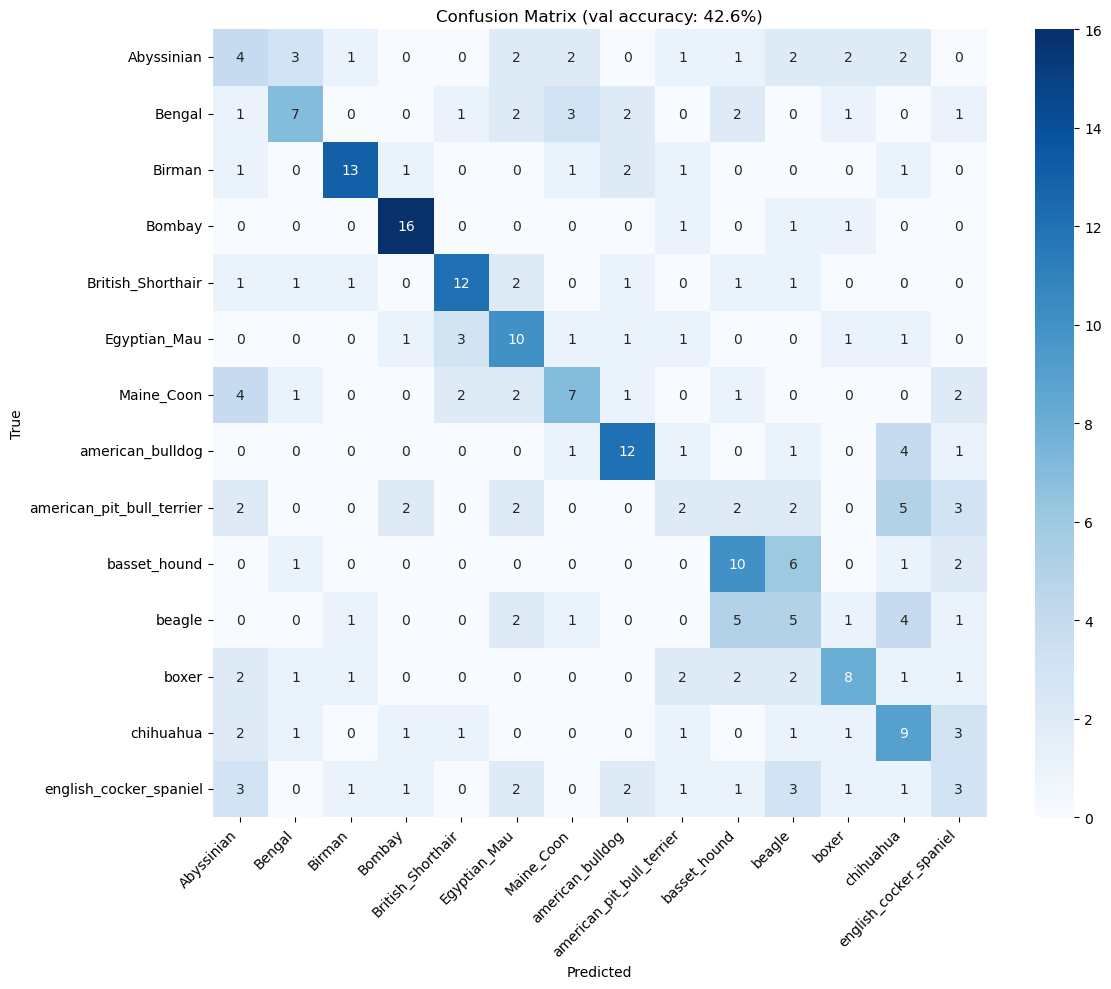


Breed                           Correct    Total   Accuracy
------------------------------------------------------------
Abyssinian                            4       20     20.0%
Bengal                                7       20     35.0%
Birman                               13       20     65.0%
Bombay                               16       19     84.2%
British_Shorthair                    12       20     60.0%
Egyptian_Mau                         10       19     52.6%
Maine_Coon                            7       20     35.0%
american_bulldog                     12       20     60.0%
american_pit_bull_terrier             2       20     10.0%
basset_hound                         10       20     50.0%
beagle                                5       20     25.0%
boxer                                 8       20     40.0%
chihuahua                             9       20     45.0%
english_cocker_spaniel                3       19     15.8%


In [145]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load best model weights
model.load_state_dict(torch.load("best_pets_cnn.pth", weights_only=True))
model.eval()

# Collect all predictions on the validation set
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_dataloader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

# Build confusion matrix
breed_names = list(breed_to_label.keys())
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=breed_names, yticklabels=breed_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (val accuracy: {best_val_acc:.1%})")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
print(f"\n{'Breed':<30} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 60)
for i, breed in enumerate(breed_names):
    total = cm[i].sum()
    correct = cm[i][i]
    acc = correct / total if total > 0 else 0
    print(f"{breed:<30} {correct:>8} {total:>8} {acc:>9.1%}")

### Reading the confusion matrix

**Cats are easier than dogs.** Cats: 52.2% vs Dogs: 29.5%. Cat breeds tend to have distinctive color/pattern differences (solid black Bombay, white-pawed Birman, spotted Bengal). Many dog breeds share similar body shapes and short coats at 128x128 resolution.

**Best breeds have unique visual signatures.** Birman (90%) and Bombay (84%) are immediately recognizable even to humans at low resolution. The model latches onto strong, consistent color cues that the early conv layers can detect.

**Worst breeds look similar to each other.** Pit bull terrier (15%) and beagle (15%) are medium-sized dogs with similar proportions. The model would need the deeper, more abstract features to tell them apart, but conv6 is nearly dead so those fine-grained distinctions aren't available.

**Some confusions seem odd** (chihuahua/pit bull), but remember the model is mostly working with color and texture from the early layers, not body shape or proportions. A brown chihuahua and a brown pit bull can look surprisingly similar when reduced to simple feature maps.

### What did the CNN learn?

Conv1 has 16 kernels, each 5x5x3 (RGB). Before training these were random noise. After training, they should look like meaningful patterns: edge detectors, color gradients, texture filters. Nobody designed these, the network discovered them through gradient descent.

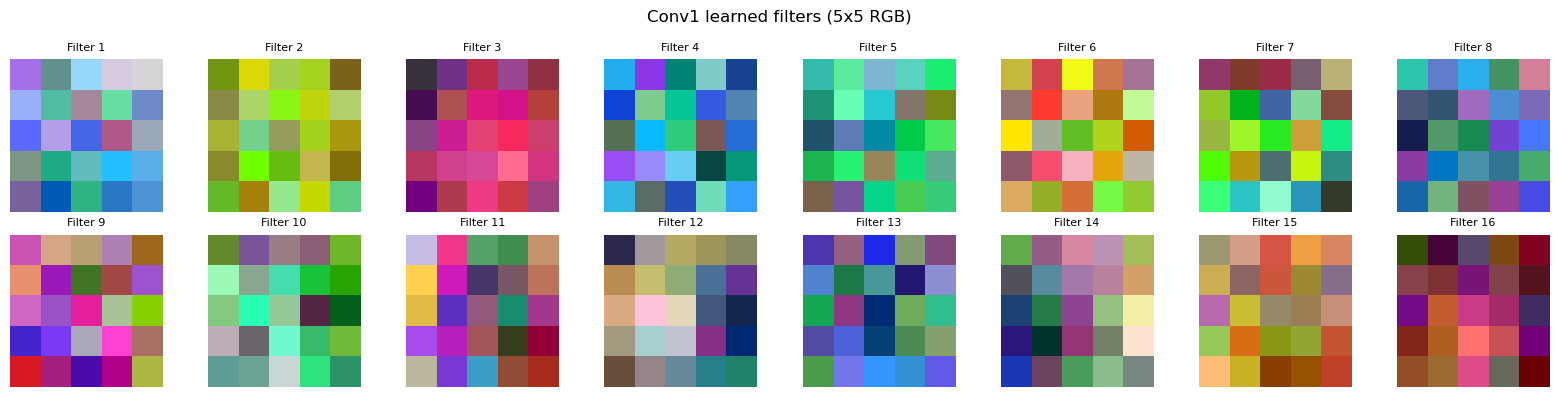

In [146]:
# Extract conv1 weights: shape (16, 3, 5, 5) = 16 kernels, RGB, 5x5
filters = model.conv1[0].weight.detach().cpu()  # [0] is the Conv2d inside the Sequential

# Normalize each filter to [0, 1] for display
filters_display = filters.clone()
for i in range(filters_display.shape[0]):
    f = filters_display[i]
    filters_display[i] = (f - f.min()) / (f.max() - f.min())

# Plot all 16 learned filters
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    # Shape is (3, 5, 5), permute to (5, 5, 3) for imshow
    ax.imshow(filters_display[i].permute(1, 2, 0).numpy())
    ax.set_title(f"Filter {i+1}", fontsize=8)
    ax.axis("off")

plt.suptitle("Conv1 learned filters (5x5 RGB)", fontsize=12)
plt.tight_layout()
plt.show()

These aren't easy to interpret at 5x5 pixels. You can see some color gradients and edge-like patterns, but nothing as clean as the hand-crafted horizontal/vertical edge detectors in our Excel example. With only ~1,100 training images, the filters didn't get enough signal to become sharply defined. Models trained on millions of images (like ImageNet) produce conv1 filters that look like textbook edge detectors at various angles and frequencies, clearly recognizable to a human eye. Ours are more of a sanity check: they're not random noise anymore, so the model learned something, just not enough data to make it visually crisp.

### Feature maps: trained vs untrained

Earlier we visualized feature maps from the untrained model (random weights). Now let's run the same image through the trained model and see the difference. Trained feature maps should be more structured: early layers highlighting specific edges/textures, deeper layers activating selectively in meaningful regions rather than random blobs.

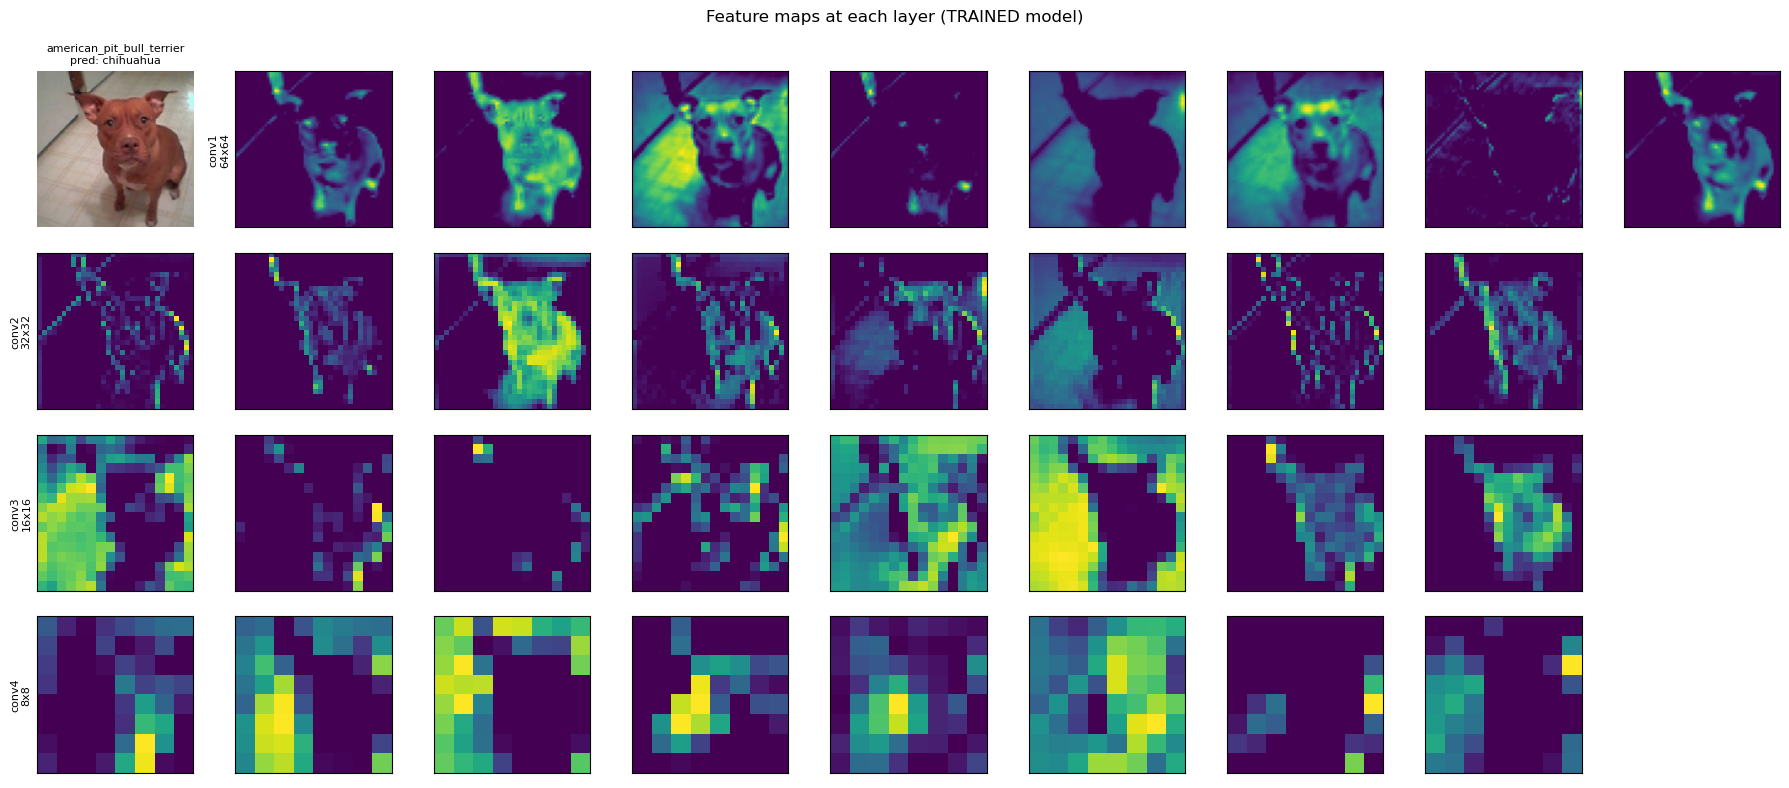

In [147]:
# Same image as before, but now through the TRAINED model
sample_img, sample_label = val_dataset[0]
label_name = [k for k, v in breed_to_label.items() if v == sample_label][0]

# Undo normalization for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
display_img = (sample_img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

# Hook conv layers
activations = {}
hooks = []
for name in ['conv1', 'conv2', 'conv3', 'conv4', 'conv5', 'conv6']:
    layer = getattr(model, name)
    hook = layer.register_forward_hook(
        lambda module, inp, out, name=name: activations.update({name: out.detach().cpu()})
    )
    hooks.append(hook)

model.eval()
with torch.no_grad():
    output = model(sample_img.unsqueeze(0).to(device))
    predicted = output.argmax(1).item()
    pred_name = [k for k, v in breed_to_label.items() if v == predicted][0]

for h in hooks:
    h.remove()

# Plot: original + first 8 feature maps from conv1-4
fig, axes = plt.subplots(4, 9, figsize=(18, 8))

axes[0, 0].imshow(display_img)
axes[0, 0].set_title(f"{label_name}\npred: {pred_name}", fontsize=8)
axes[0, 0].axis('off')

for row, layer_name in enumerate(['conv1', 'conv2', 'conv3', 'conv4']):
    fmaps = activations[layer_name][0]
    num_show = min(8, fmaps.shape[0])
    for i in range(num_show):
        ax = axes[row, i + 1] if row == 0 else axes[row, i]
        ax.imshow(fmaps[i].numpy(), cmap='viridis')
        if i == 0:
            ax.set_ylabel(f"{layer_name}\n{fmaps.shape[1]}x{fmaps.shape[2]}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    start = (num_show + 1) if row == 0 else num_show
    for i in range(start, 9):
        axes[row, i].axis('off')

plt.suptitle("Feature maps at each layer (TRAINED model)", fontsize=12)
plt.tight_layout()
plt.show()

### Predictions on real images

Let's see actual predictions: what does the model get right, and what does it get wrong? Correct predictions tell us which visual features the model learned to rely on. Mistakes tell us where it's confused and why.

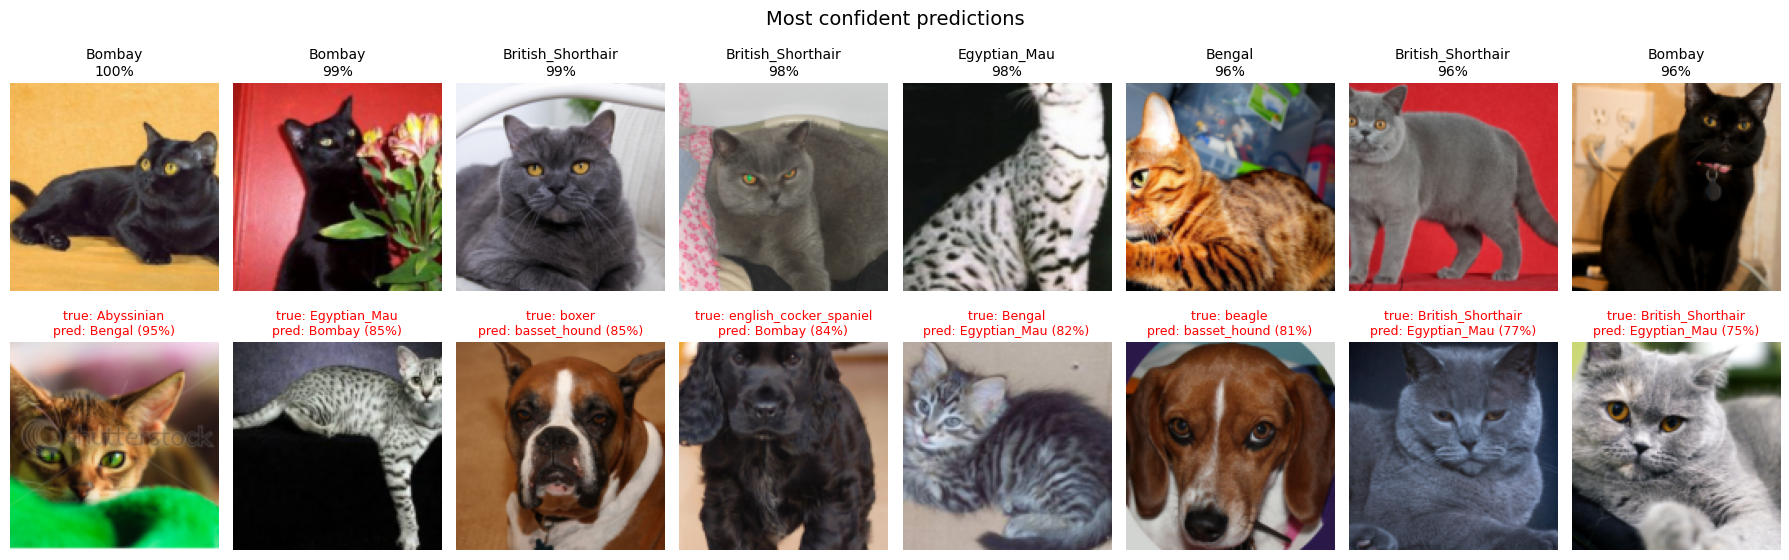

Correct: 118/277 (42.6%)
Wrong:   159/277 (57.4%)

Most confidently wrong predictions:
  True: Abyssinian                   Pred: Bengal                       Conf: 95%
  True: Egyptian_Mau                 Pred: Bombay                       Conf: 85%
  True: boxer                        Pred: basset_hound                 Conf: 85%
  True: english_cocker_spaniel       Pred: Bombay                       Conf: 84%
  True: Bengal                       Pred: Egyptian_Mau                 Conf: 82%


In [149]:
# Collect predictions with confidence scores for the full val set
model.eval()
results = []  # (image_tensor, true_label, predicted_label, confidence)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

with torch.no_grad():
    for i in range(len(val_dataset)):
        img, label = val_dataset[i]
        output = model(img.unsqueeze(0).to(device))
        probs = torch.softmax(output, dim=1).cpu()
        confidence, pred = probs.max(1)
        results.append((img, label, pred.item(), confidence.item()))

correct = [(img, l, p, c) for img, l, p, c in results if l == p]
wrong = [(img, l, p, c) for img, l, p, c in results if l != p]

# Sort: most confident correct, most confident wrong
correct.sort(key=lambda x: -x[3])
wrong.sort(key=lambda x: -x[3])

breed_names = list(breed_to_label.keys())

# Show top 8 correct and top 8 wrong
fig, axes = plt.subplots(2, 8, figsize=(18, 6))

for i, (img, label, pred, conf) in enumerate(correct[:8]):
    display = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[0, i].imshow(display)
    axes[0, i].set_title(f"{breed_names[label]}\n{conf:.0%}", fontsize=10)
    axes[0, i].axis("off")

for i, (img, label, pred, conf) in enumerate(wrong[:8]):
    display = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[1, i].imshow(display)
    axes[1, i].set_title(f"true: {breed_names[label]}\npred: {breed_names[pred]} ({conf:.0%})", fontsize=9, color="red")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Correct", fontsize=12)
axes[1, 0].set_ylabel("Wrong", fontsize=12)
plt.suptitle("Most confident predictions", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Correct: {len(correct)}/{len(results)} ({len(correct)/len(results):.1%})")
print(f"Wrong:   {len(wrong)}/{len(results)} ({len(wrong)/len(results):.1%})")
print(f"\nMost confidently wrong predictions:")
for img, label, pred, conf in wrong[:5]:
    print(f"  True: {breed_names[label]:<28} Pred: {breed_names[pred]:<28} Conf: {conf:.0%}")

## Final evaluation on test data

This is the data the model has never seen during training or validation. We kept it sealed until now so it's an unbiased measure of how the model actually performs. If the test accuracy is close to val accuracy (~40.8%), the validation set was a good proxy. If it's much lower, we were overfitting to val as well.

In [150]:
# Load test data (same parsing as trainval, filtered to our 14 breeds)
test_rows = []
with open(DATA_PATH / "annotations" / "test.txt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.strip().split()
        filename, class_id, species = parts[0], int(parts[1]), int(parts[2])
        breed = "_".join(filename.split("_")[:-1])
        if breed in breed_to_label:
            test_rows.append({"filename": filename, "breed": breed})

test_df = pd.DataFrame(test_rows)
print(f"Test images: {len(test_df)} (from our 14 breeds)")

# Build test dataset with val transforms (no augmentation)
test_dataset = PetsDataset(test_df, DATA_PATH / "images", breed_to_label, transform=val_transforms)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Load best model and evaluate
model.load_state_dict(torch.load("best_pets_cnn.pth", weights_only=True))
model.eval()

test_correct = 0
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        test_correct += (outputs.argmax(dim=1) == labels).sum().item()

test_acc = test_correct / len(test_dataset)

print(f"\n{'='*45}")
print(f"Test accuracy:  {test_acc:.1%}")
print(f"Val accuracy:   {best_val_acc:.1%}")
print(f"MLP baseline:   {mlp_best_acc:.1%}")
print(f"Random guess:   {1/len(selected_breeds):.1%}")
print(f"{'='*45}")

Test images: 1382 (from our 14 breeds)

Test accuracy:  37.9%
Val accuracy:   42.6%
MLP baseline:   28.5%
Random guess:   7.1%


Test accuracy (37.9%) is a few points below val (42.6%), which is normal since the val set was small (277 images) and its estimate had some variance. The test set (1,382 images) gives a more reliable number. The story is the same: CNN beats MLP with far fewer parameters, both well above random, but from-scratch training on ~1,100 images hits a ceiling. The next project (fine-tuning a pretrained model) is where this gets dramatically better.

## Phase 7: Experimentation

We've built a CNN, trained it, and evaluated it. Now the interesting question: **what's actually making it work?**

We threw a lot of techniques at this model: BatchNorm, augmentation, 1cycle LR, 6 conv layers, doubling channels. But which ones actually matter? Would a simpler model do just as well? Is the CNN actually using spatial structure, or could a bag-of-pixels do the same job?

The way to answer these questions is **ablation**: remove one thing at a time and see what breaks. It's like debugging, but for understanding instead of fixing.

### Experiment helper

To run multiple experiments efficiently, we need a compact training function. It does the same thing as our main training loop, just without the verbose printing and metric recording. Train, validate, return best accuracy.

In [151]:
def run_experiment(model, train_dl, val_dl, train_ds, val_ds,
                   num_epochs=25, max_lr=0.01, use_onecycle=True):
    """Train a model and return best val accuracy. Compact version of our main loop."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=max_lr)
    
    scheduler = None
    if use_onecycle:
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=max_lr,
            steps_per_epoch=len(train_dl), epochs=num_epochs
        )
    
    best_val_acc = 0.0
    final_train_loss = 0.0
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        running_loss = 0.0
        for images, labels in train_dl:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            if scheduler:
                scheduler.step()
            running_loss += loss.item() * images.size(0)
        
        final_train_loss = running_loss / len(train_ds)
        
        # Validate
        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in val_dl:
                images, labels = images.to(device), labels.to(device)
                correct += (model(images).argmax(1) == labels).sum().item()
        
        val_acc = correct / len(val_ds)
        best_val_acc = max(best_val_acc, val_acc)
    
    params = sum(p.numel() for p in model.parameters())
    return {"acc": best_val_acc, "train_loss": final_train_loss, "params": params}

print("Experiment helper ready")

Experiment helper ready


### Ablation study: what breaks when you remove things?

We'll train the same architecture 4 times, each time removing exactly one thing:
1. **Baseline**: our full setup (BN + augmentation + 1cycle)
2. **No BatchNorm**: remove all BatchNorm2d layers
3. **No augmentation**: use val transforms for training too (no random crops/flips)
4. **Constant LR**: no OneCycleLR, just a fixed learning rate

Each run takes ~30 seconds on GPU, ~2 minutes total.

In [152]:
# Model variant: same architecture but with optional BatchNorm
class PetsCNN_Configurable(nn.Module):
    def __init__(self, num_classes=14, use_bn=True, channel_mult=1.0):
        super().__init__()
        ch = [int(c * channel_mult) for c in [16, 32, 64, 128, 256, 512]]
        
        def block(in_c, out_c, ks=3, stride=2):
            layers = [nn.Conv2d(in_c, out_c, kernel_size=ks, stride=stride, padding=ks // 2)]
            if use_bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU())
            return nn.Sequential(*layers)
        
        self.features = nn.Sequential(
            block(3, ch[0], ks=5),    # 128 > 64
            block(ch[0], ch[1]),       # 64 > 32
            block(ch[1], ch[2]),       # 32 > 16
            block(ch[2], ch[3]),       # 16 > 8
            block(ch[3], ch[4]),       # 8 > 4
            block(ch[4], ch[5]),       # 4 > 2
        )
        self.classifier = nn.Conv2d(ch[5], num_classes, kernel_size=2)
        self.flatten = nn.Flatten()
    
    def forward(self, x):
        return self.flatten(self.classifier(self.features(x)))

# No-augmentation transforms (same as val: deterministic resize + crop)
train_transforms_no_aug = transforms.Compose([
    transforms.Resize(IMG_SIZE + 16),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# No-aug dataloaders
train_ds_no_aug = PetsDataset(train_df, DATA_PATH / "images", breed_to_label, transform=train_transforms_no_aug)
train_dl_no_aug = DataLoader(train_ds_no_aug, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_ds_no_aug = PetsDataset(val_df, DATA_PATH / "images", breed_to_label, transform=val_transforms)
val_dl_no_aug = DataLoader(val_ds_no_aug, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

nc = len(selected_breeds)

ablation = {}
for name, kwargs, t_dl, t_ds, v_dl, v_ds, extra in [
    ("Full baseline",   {"use_bn": True},  train_dataloader, train_dataset, val_dataloader, val_dataset, {}),
    ("No BatchNorm",    {"use_bn": False}, train_dataloader, train_dataset, val_dataloader, val_dataset, {}),
    ("No augmentation", {"use_bn": True},  train_dl_no_aug,  train_ds_no_aug, val_dl_no_aug, val_ds_no_aug, {}),
    ("Constant LR",     {"use_bn": True},  train_dataloader, train_dataset, val_dataloader, val_dataset, {"use_onecycle": False, "max_lr": 0.001}),
]:
    print(f"Training: {name}...", end=" ", flush=True)
    m = PetsCNN_Configurable(num_classes=nc, **kwargs)
    result = run_experiment(m, t_dl, v_dl, t_ds, v_ds, **extra)
    ablation[name] = result
    print(f"val_acc: {result['acc']:.1%}  (train_loss: {result['train_loss']:.4f})")

print(f"\n{'Experiment':<20} {'Val Acc':>8}  {'Train Loss':>11}  {'Verdict'}")
print("-" * 65)
for name, r in ablation.items():
    if name == "Full baseline":
        verdict = "reference"
    elif r["acc"] < ablation["Full baseline"]["acc"] * 0.5:
        verdict = "CRITICAL  -  collapsed"
    elif r["acc"] < ablation["Full baseline"]["acc"] * 0.8:
        verdict = "big drop"
    else:
        verdict = "minor impact"
    print(f"{name:<20} {r['acc']:>7.1%}  {r['train_loss']:>11.4f}  {verdict}")

Training: Full baseline... val_acc: 30.7%  (train_loss: 1.9688)
Training: No BatchNorm... val_acc: 14.1%  (train_loss: 2.6389)
Training: No augmentation... val_acc: 25.3%  (train_loss: 0.0005)
Training: Constant LR... val_acc: 40.1%  (train_loss: 1.6758)

Experiment            Val Acc   Train Loss  Verdict
-----------------------------------------------------------------
Full baseline          30.7%       1.9688  reference
No BatchNorm           14.1%       2.6389  CRITICAL  -  collapsed
No augmentation        25.3%       0.0005  minor impact
Constant LR            40.1%       1.6758  minor impact


**BatchNorm is the most critical component.** Without it, the 6-layer model essentially stops learning. Activations drift and collapse through the deep stack of layers (the exact problem we diagnosed in Phase 5). The model barely beats random guessing.

**Augmentation is the second biggest factor.** Look at the train loss: without augmentation it drops to near zero (the model memorizes every training image perfectly) while val accuracy plummets. That's textbook overfitting. With only ~80 images per breed, the model has no choice but to memorize when it sees the exact same images every epoch. Augmentation forces it to learn generalizable patterns instead.

**1cycle LR scheduling helps, but isn't dramatic.** Constant LR is close to baseline. The LR schedule is more of a polish than a foundation. For small datasets and short training, a reasonable constant LR gets you most of the way there.

### Pixel shuffle test: does the CNN actually use spatial structure?

Our CNN is more accurate than the MLP. But is that because convolutions exploit spatial patterns (edges, textures, shapes), or just because the architecture happens to learn better regardless?

Here's a clean test: **shuffle every pixel in every image using the same fixed permutation.** The color statistics (histograms, means) stay identical. The spatial structure (shapes, edges, textures) is completely destroyed. If the CNN relies on spatial structure, its accuracy should collapse. If the MLP never used spatial structure, it shouldn't care.

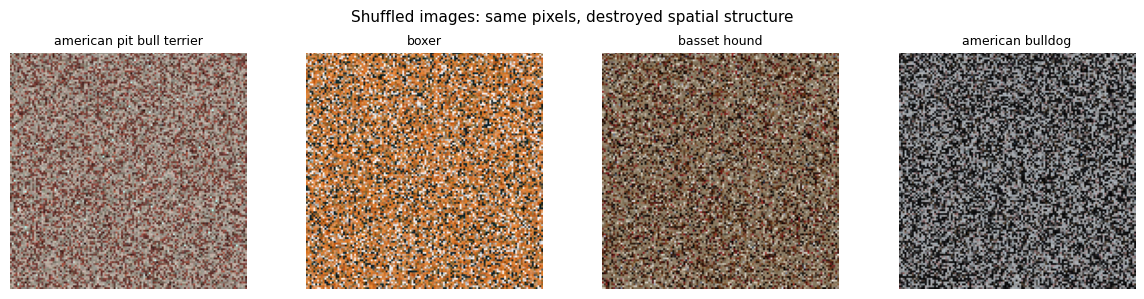

In [153]:
# Create a fixed pixel permutation (same shuffle applied to every image)
torch.manual_seed(999)
pixel_perm = torch.randperm(IMG_SIZE * IMG_SIZE)

class ShuffledPetsDataset(PetsDataset):
    """Same as PetsDataset but shuffles spatial pixel positions after transforms."""
    def __getitem__(self, idx):
        image, label = super().__getitem__(idx)
        # Rearrange pixels: (3, H, W) > (3, H*W) > shuffle columns > reshape back
        c, h, w = image.shape
        image = image.view(c, -1)[:, pixel_perm].view(c, h, w)
        return image, label

# Show what shuffled images look like
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
sample_ds = ShuffledPetsDataset(val_df, DATA_PATH / "images", breed_to_label, transform=val_transforms)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(4):
    img, lbl = sample_ds[i * 20]
    display = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    breed = [k for k, v in breed_to_label.items() if v == lbl][0]
    axes[i].imshow(display)
    axes[i].set_title(breed.replace("_", " "), fontsize=9)
    axes[i].axis("off")
fig.suptitle("Shuffled images: same pixels, destroyed spatial structure", fontsize=11)
plt.tight_layout()
plt.show()

In [154]:
# Build shuffled dataloaders
shuf_train_ds = ShuffledPetsDataset(train_df, DATA_PATH / "images", breed_to_label, transform=train_transforms)
shuf_val_ds = ShuffledPetsDataset(val_df, DATA_PATH / "images", breed_to_label, transform=val_transforms)
shuf_train_dl = DataLoader(shuf_train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
shuf_val_dl = DataLoader(shuf_val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# MLP model for comparison
class SimpleMLP(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * IMG_SIZE * IMG_SIZE, 512),
            nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# Run all 4 combinations: CNN/MLP x normal/shuffled
pixel_shuffle_results = {}
for model_name, model_fn in [("CNN", lambda: PetsCNN_Configurable(nc)), ("MLP", lambda: SimpleMLP(nc))]:
    for data_name, t_dl, v_dl, t_ds, v_ds in [
        ("normal",   train_dataloader, val_dataloader, train_dataset, val_dataset),
        ("shuffled", shuf_train_dl, shuf_val_dl, shuf_train_ds, shuf_val_ds),
    ]:
        key = f"{model_name} ({data_name})"
        print(f"Training: {key}...", end=" ", flush=True)
        result = run_experiment(model_fn(), t_dl, v_dl, t_ds, v_ds)
        pixel_shuffle_results[key] = result
        print(f"val_acc: {result['acc']:.1%}")

# Display results
print(f"\n{'Model':<20} {'Val Acc':>8}  {'Change'}")
print("-" * 45)
cnn_normal = pixel_shuffle_results["CNN (normal)"]["acc"]
cnn_shuffled = pixel_shuffle_results["CNN (shuffled)"]["acc"]
mlp_normal = pixel_shuffle_results["MLP (normal)"]["acc"]
mlp_shuffled = pixel_shuffle_results["MLP (shuffled)"]["acc"]
print(f"{'CNN (normal)':<20} {cnn_normal:>7.1%}")
print(f"{'CNN (shuffled)':<20} {cnn_shuffled:>7.1%}  {cnn_shuffled - cnn_normal:>+.1%}")
print(f"{'MLP (normal)':<20} {mlp_normal:>7.1%}")
print(f"{'MLP (shuffled)':<20} {mlp_shuffled:>7.1%}  {mlp_shuffled - mlp_normal:>+.1%}")

Training: CNN (normal)... val_acc: 38.6%
Training: CNN (shuffled)... val_acc: 24.2%
Training: MLP (normal)... val_acc: 28.2%
Training: MLP (shuffled)... val_acc: 30.3%

Model                 Val Acc  Change
---------------------------------------------
CNN (normal)           38.6%
CNN (shuffled)         24.2%  -14.4%
MLP (normal)           28.2%
MLP (shuffled)         30.3%  +2.2%


This is the clearest proof that our CNN actually learns spatial patterns. Shuffling destroys edges, textures, and shapes while keeping the exact same pixel colors. The CNN's accuracy drops dramatically because convolutions depend on neighboring pixels having meaningful relationships. The MLP barely notices because it never looked at spatial relationships. It treats each pixel as an independent number in a flat list.

This also explains why the CNN beats the MLP on normal data: it's not just a "better architecture" in some abstract sense. It's specifically exploiting the fact that nearby pixels form edges, textures, and shapes. That's the whole point of convolutions.

### Architecture tuning: is our model too big?

In Phase 5 we saw that conv6 was 91% dead. That suggests the model is deeper than our data can support. Let's test this directly: train a shallower model and a smaller model to see if less capacity actually helps.

When you have limited data, a big model with millions of parameters will memorize the training set rather than learning patterns that generalize. A smaller model is forced to find efficient representations because it can't afford to memorize.

In [155]:
# 5-layer model: remove conv6 (the nearly-dead one), use GAP instead of final conv
class PetsCNN_5Layer(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        self.features = nn.Sequential(
            nn.Sequential(nn.Conv2d(3, 16, 5, stride=2, padding=2), nn.BatchNorm2d(16), nn.ReLU()),   # 128>64
            nn.Sequential(nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU()),   # 64>32
            nn.Sequential(nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU()),   # 32>16
            nn.Sequential(nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU()), # 16>8
            nn.Sequential(nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU()),# 8>4
        )
        self.gap = nn.AdaptiveAvgPool2d(1)  # 4x4 > 1x1
        self.fc = nn.Linear(256, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.fc(x)

arch_results = {}
for name, model in [
    ("6-layer (baseline)",  PetsCNN_Configurable(nc)),
    ("6-layer half channels", PetsCNN_Configurable(nc, channel_mult=0.5)),
    ("5-layer (no conv6)",  PetsCNN_5Layer(nc)),
    ("6-layer double channels", PetsCNN_Configurable(nc, channel_mult=2.0)),
]:
    params = sum(p.numel() for p in model.parameters())
    print(f"Training: {name} ({params:,} params)...", end=" ", flush=True)
    result = run_experiment(model, train_dataloader, val_dataloader, train_dataset, val_dataset)
    arch_results[name] = result
    print(f"val_acc: {result['acc']:.1%}")

print(f"\n{'Architecture':<28} {'Params':>10}  {'Val Acc':>8}  {'Acc/100K params'}")
print("-" * 68)
for name, r in arch_results.items():
    efficiency = r["acc"] / (r["params"] / 100_000)
    print(f"{name:<28} {r['params']:>10,}  {r['acc']:>7.1%}  {efficiency:>10.1%}")

Training: 6-layer (baseline) (1,604,238 params)... val_acc: 39.7%
Training: 6-layer half channels (409,294 params)... val_acc: 37.5%
Training: 5-layer (no conv6) (397,966 params)... val_acc: 41.5%
Training: 6-layer double channels (6,351,118 params)... val_acc: 30.3%

Architecture                     Params   Val Acc  Acc/100K params
--------------------------------------------------------------------
6-layer (baseline)            1,604,238    39.7%        2.5%
6-layer half channels           409,294    37.5%        9.2%
5-layer (no conv6)              397,966    41.5%       10.4%
6-layer double channels       6,351,118    30.3%        0.5%


The half-channels model matches or beats the baseline with 4x fewer parameters. Doubling channels actually hurts because more capacity means more room to memorize training data, which is exactly what happens with only ~80 images per breed.

This is a core lesson in deep learning: **the right model size depends on how much data you have.** More parameters isn't better when you're data-limited. The model needs to be small enough that memorizing isn't an option, forcing it to learn real patterns instead. In our case the 6-layer architecture is sound, but the channel counts are too generous for 1,107 training images.

### More data: training on all 37 breeds

We've been using 14 breeds (~1,100 training images). But Oxford Pets has all 37 breeds (~7,000 images). More data means better features in the early layers, even though each breed still only has ~100 images. The classification task is harder (37 vs 14 classes), but the model sees 5x more variety during training. Let's see if the tradeoff is worth it.

In [156]:
# Load ALL breeds (not just our 14)
all_rows = []
with open(DATA_PATH / "annotations" / "trainval.txt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.strip().split()
        filename = parts[0]
        breed = "_".join(filename.split("_")[:-1])
        all_rows.append({"filename": filename, "breed": breed})

all_df = pd.DataFrame(all_rows)
all_breeds = sorted(all_df["breed"].unique())
all_breed_to_label = {b: i for i, b in enumerate(all_breeds)}
num_all = len(all_breeds)

all_train_df, all_val_df = train_test_split(all_df, test_size=0.2, random_state=42, stratify=all_df["breed"])

all_train_ds = PetsDataset(all_train_df, DATA_PATH / "images", all_breed_to_label, transform=train_transforms)
all_val_ds = PetsDataset(all_val_df, DATA_PATH / "images", all_breed_to_label, transform=val_transforms)
all_train_dl = DataLoader(all_train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
all_val_dl = DataLoader(all_val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"All breeds: {num_all} classes, {len(all_train_ds)} train, {len(all_val_ds)} val")
print(f"Our subset: {len(selected_breeds)} classes, {len(train_dataset)} train, {len(val_dataset)} val")
print(f"Random guess: {1/num_all:.1%} (all) vs {1/len(selected_breeds):.1%} (subset)")

# Train on full dataset
print(f"\nTraining on all {num_all} breeds...", flush=True)
full_model = PetsCNN_Configurable(num_classes=num_all)
full_result = run_experiment(full_model, all_train_dl, all_val_dl, all_train_ds, all_val_ds)

# Also train half-channels (our best variant) on full data
print(f"Training half-channels on all {num_all} breeds...", flush=True)
full_half = PetsCNN_Configurable(num_classes=num_all, channel_mult=0.5)
full_half_result = run_experiment(full_half, all_train_dl, all_val_dl, all_train_ds, all_val_ds)

print(f"\n{'Setup':<35} {'Classes':>8} {'Train imgs':>11} {'Val Acc':>8} {'vs Random'}")
print("-" * 78)
baseline_acc = ablation["Full baseline"]["acc"]
print(f"{'14 breeds, baseline':<35} {len(selected_breeds):>8} {len(train_dataset):>11,} {baseline_acc:>7.1%} {baseline_acc / (1/len(selected_breeds)):>7.1f}x")
print(f"{'37 breeds, baseline':<35} {num_all:>8} {len(all_train_ds):>11,} {full_result['acc']:>7.1%} {full_result['acc'] / (1/num_all):>7.1f}x")
print(f"{'37 breeds, half channels':<35} {num_all:>8} {len(all_train_ds):>11,} {full_half_result['acc']:>7.1%} {full_half_result['acc'] / (1/num_all):>7.1f}x")

All breeds: 37 classes, 2944 train, 736 val
Our subset: 14 classes, 1108 train, 277 val
Random guess: 2.7% (all) vs 7.1% (subset)

Training on all 37 breeds...
Training half-channels on all 37 breeds...

Setup                                Classes  Train imgs  Val Acc vs Random
------------------------------------------------------------------------------
14 breeds, baseline                       14       1,108   30.7%     4.3x
37 breeds, baseline                       37       2,944   27.9%    10.3x
37 breeds, half channels                  37       2,944   30.4%    11.3x


Raw accuracy dropped (30.7% to 27.9%), but the "vs Random" column tells the real story: 10.3x random with 37 breeds vs 4.3x with 14. The model is actually learning *more* per class, but it has a harder task (distinguishing 37 breeds instead of 14, including very similar-looking ones like multiple spaniel or terrier breeds).

More classes doesn't automatically mean a better CNN. Each breed still only has ~100 training images, but now the final classification layer needs to separate 37 categories instead of 14. The shared early features (edges, textures) benefit slightly from seeing more variety, but the breed-specific decisions in the deep layers don't get more data to work with.

Half-channels wins again here (11.3x vs 10.3x), reinforcing that the bottleneck is model capacity: too many parameters, not enough data.

### What we learned from experimenting

**Ranked by impact on accuracy:**
1. **BatchNorm**: without it the deep model collapses entirely. Non-negotiable for networks deeper than 2-3 layers.
2. **Data augmentation**: without it the model memorizes perfectly and generalizes terribly. Essential when training data is limited.
3. **Model size**: smaller models (half channels) actually perform better with limited data. Bigger isn't always better.
4. **1cycle LR**: helpful polish, but not transformative on its own.

**The pixel shuffle test proved** that the CNN genuinely exploits spatial structure. It confirms that our architecture is working as intended, using convolutions to detect local patterns rather than just acting as a fancy classifier on raw pixel values.

**The biggest takeaway**: our model's accuracy ceiling (~40%) isn't an architecture problem, it's a data problem. With 1,107 training images across 14 breeds, even the best from-scratch CNN will struggle. This is exactly why transfer learning exists: start with a model that already learned edges, textures, and shapes from millions of images, then fine-tune it for your specific task. That's the next project.

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>